## Fine-tuned multiGradICON: CT–US registration demo

This notebook runs inference with a **local fine-tuned multiGradICON checkpoint** on your CT and US volumes. Registration direction: **US (moving) → CT (fixed)** — i.e. align US to CT. Uses input shape 175×175×175 and optional masks.

### Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import itk
import matplotlib.pyplot as plt
from unigradicon import get_multigradicon

### Paths and constants

In [7]:
# Fine-tuned multiGradICON checkpoint (required).
CHECKPOINT_PATH = r"C:\Users\Gabriella\Documents\test_data\Finetune_multi_final.trch"

# Test data directory and image paths.
# Registration: US (moving) -> CT (fixed). Reference = CT, to align = US.
TEST_DATA_DIR = r"C:\Users\Gabriella\Documents\test_data"
PATH_FIXED_CT = os.path.join(TEST_DATA_DIR, "258L_imgCT.nii")
PATH_MOVING_US = os.path.join(TEST_DATA_DIR, "258L_imgUS.nii")

# Optional: mask paths for masking background before registration.
PATH_MASK_US = os.path.join(TEST_DATA_DIR, "258L_maskUS.nii.gz")
PATH_MASK_CT = os.path.join(TEST_DATA_DIR, "258L_maskCT.nii.gz")
if not os.path.isfile(PATH_MASK_US):
    PATH_MASK_US = None
if not os.path.isfile(PATH_MASK_CT):
    PATH_MASK_CT = None

INPUT_SHAPE = (175, 175, 175)

### Load and inspect images

In [6]:
# Optional: reorient to RAS for consistency with finetuning dataset.
try:
    from unigradicon.finetuning.dataset import reorient
    use_reorient = True
except ImportError:
    use_reorient = False

def load_volume(path):
    img = itk.imread(path)
    if use_reorient:
        img = reorient(img)
    arr = np.asarray(img)
    meta = dict(img)
    return arr, meta

ct_arr, ct_meta = load_volume(PATH_FIXED_CT)
us_arr, us_meta = load_volume(PATH_MOVING_US)

print(f"CT (fixed) shape: {ct_arr.shape}")
print(f"CT spacing: {ct_meta.get('spacing', 'N/A')}")
print(f"US (moving) shape: {us_arr.shape}")
print(f"US spacing: {us_meta.get('spacing', 'N/A')}")

mask_us_arr = None
mask_ct_arr = None
if PATH_MASK_US and os.path.isfile(PATH_MASK_US):
    mask_us_arr, _ = load_volume(PATH_MASK_US)
    print(f"US mask shape: {mask_us_arr.shape}")
if PATH_MASK_CT and os.path.isfile(PATH_MASK_CT):
    mask_ct_arr, _ = load_volume(PATH_MASK_CT)
    print(f"CT mask shape: {mask_ct_arr.shape}")

Template itk::FixedArray<double,2>
 already defined as <class 'itk.itkFixedArrayPython.itkFixedArrayD2'>
 is redefined as <class 'itk.itkFixedArrayPython.itkFixedArrayD2'>
Template itk::FixedArray<float,2>
 already defined as <class 'itk.itkFixedArrayPython.itkFixedArrayF2'>
 is redefined as <class 'itk.itkFixedArrayPython.itkFixedArrayF2'>
Template itk::FixedArray<unsignedlong,2>
 already defined as <class 'itk.itkFixedArrayPython.itkFixedArrayUL2'>
 is redefined as <class 'itk.itkFixedArrayPython.itkFixedArrayUL2'>
Template itk::FixedArray<unsignedlonglong,2>
 already defined as <class 'itk.itkFixedArrayPython.itkFixedArrayULL2'>
 is redefined as <class 'itk.itkFixedArrayPython.itkFixedArrayULL2'>
Template itk::FixedArray<unsignedshort,2>
 already defined as <class 'itk.itkFixedArrayPython.itkFixedArrayUS2'>
 is redefined as <class 'itk.itkFixedArrayPython.itkFixedArrayUS2'>
Template itk::FixedArray<unsignedchar,2>
 already defined as <class 'itk.itkFixedArrayPython.itkFixedArrayUC2'

CT (fixed) shape: (95, 106, 111)
CT spacing: [1.5        0.81640625 0.81640625]
US (moving) shape: (645, 768, 1024)
US spacing: [0.30000001 0.30000001 0.30000001]
US mask shape: (645, 768, 1024)
CT mask shape: (95, 106, 111)


### Preprocessing

In [8]:
def preprocess(img, modality="ct"):
    """img: numpy array or tensor, modality in ('ct', 'us'). Returns tensor [1,1,D,H,W]."""
    if not isinstance(img, torch.Tensor):
        img = torch.tensor(img, dtype=torch.float32)
    img = img[None, None].float()
    img = F.interpolate(img, INPUT_SHAPE, mode="trilinear", align_corners=False)
    if modality == "ct":
        clamp = (-1000, 1000)
        img = torch.clamp(img, clamp[0], clamp[1])
        img = (img - clamp[0]) / (clamp[1] - clamp[0])
    else:
        im_min = torch.quantile(img.view(-1), 0.01)
        im_max = torch.quantile(img.view(-1), 0.99)
        img = torch.clamp(img, im_min, im_max)
        img = (img - im_min) / (im_max - im_min + 1e-8)
    return img

def preprocess_mask(mask_arr):
    """Resample mask to INPUT_SHAPE (nearest), return tensor [1,1,D,H,W]."""
    m = torch.tensor(mask_arr, dtype=torch.float32)[None, None]
    m = F.interpolate(m, INPUT_SHAPE, mode="nearest")
    return m

us_tensor = preprocess(us_arr, "us")
ct_tensor = preprocess(ct_arr, "ct")

if mask_us_arr is not None:
    mask_us = preprocess_mask(mask_us_arr)
    us_tensor = us_tensor * mask_us
if mask_ct_arr is not None:
    mask_ct = preprocess_mask(mask_ct_arr)
    ct_tensor = ct_tensor * mask_ct

print(f"US tensor shape: {us_tensor.shape}")
print(f"CT tensor shape: {ct_tensor.shape}")

US tensor shape: torch.Size([1, 1, 175, 175, 175])
CT tensor shape: torch.Size([1, 1, 175, 175, 175])


### Load model

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
net = get_multigradicon(weights_location=CHECKPOINT_PATH)
net.to(device)
net.eval()

Using device: cpu
Loading weights from C:\Users\Gabriella\Documents\test_data\Finetune_multi_final.trch


GradientICONSparse(
  (regis_net): TwoStepRegistration(
    (netPhi): TwoStepRegistration(
      (netPhi): DownsampleRegistration(
        (net): TwoStepRegistration(
          (netPhi): DownsampleRegistration(
            (net): FunctionFromVectorField(
              (net): UNet2(
                (downConvs): ModuleList(
                  (0): Conv3d(2, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (1): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (2): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (3): Conv3d(64, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (4): Conv3d(256, 512, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                )
                (upConvs): ModuleList(
                  (0): ConvTranspose3d(48, 16, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
                  (1

### Run inference

In [11]:
# moving = US, fixed = CT. warped_image_A = US warped to CT space.
with torch.no_grad():
    net(us_tensor.to(device), ct_tensor.to(device))

### Visualization

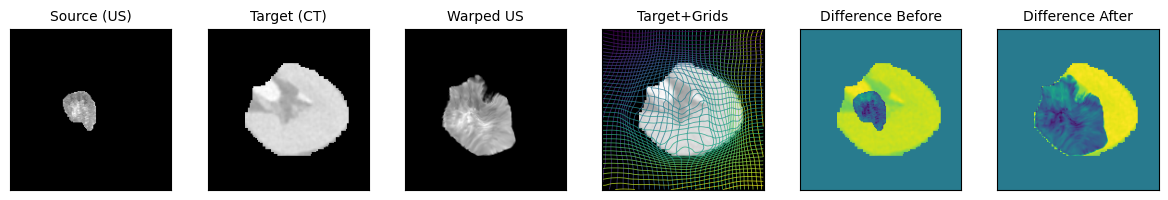

In [12]:
def show_as_grid_contour(ax, phi, linewidth=1, stride=8, flip=False):
    data_size = phi.size()[1:]
    plot_phi = phi.cpu() - 0.5
    N = plot_phi.size()[-1]
    ax.contour(plot_phi[1], np.linspace(0, N, int(N/stride)), linewidths=linewidth, alpha=0.8)
    ax.contour(plot_phi[0], np.linspace(0, N, int(N/stride)), linewidths=linewidth, alpha=0.8)
    if flip:
        ax.set_ylim([0, data_size[0]])

def show_pair(source, target, warped, phi, axes, idx, flip=False):
    shape_t = torch.tensor(INPUT_SHAPE, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1) - 1
    phi_scaled = phi * shape_t
    if flip:
        origin = 'lower'
    else:
        origin = 'upper'
    axes[0].imshow(source.cpu()[0,0,idx], cmap="gray", origin=origin)
    axes[1].imshow(target.cpu()[0,0,idx], cmap="gray", origin=origin)
    axes[2].imshow(warped.cpu()[0,0,idx], cmap="gray", origin=origin)
    axes[3].imshow(target.cpu()[0,0,idx], cmap="gray", origin=origin)
    show_as_grid_contour(axes[3], phi_scaled[0, [1,2], idx], linewidth=0.6, stride=4, flip=flip)
    axes[4].imshow(target.cpu()[0,0,idx] - source.cpu()[0,0,idx], origin=origin)
    axes[5].imshow(target.cpu()[0,0,idx] - warped.cpu()[0,0,idx], origin=origin)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
show_pair(us_tensor, ct_tensor, net.warped_image_A, net.phi_AB_vectorfield.cpu(), axes, 87)

font_size = 10
axes[0].set_title('Source (US)', fontsize=font_size)
axes[1].set_title('Target (CT)', fontsize=font_size)
axes[2].set_title('Warped US', fontsize=font_size)
axes[3].set_title('Target+Grids', fontsize=font_size)
axes[4].set_title('Difference Before', fontsize=font_size)
axes[5].set_title('Difference After', fontsize=font_size)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()